# Day 2 Inj-PT spatial fate analysis: left kidney

This notebook asks whether stGP resolves biologically meaningful heterogeneity within day 2 injured proximal tubule (Inj-PT) cells. The biological prior is that day 2 is a repair decision point: some Inj-PT cells recover toward healthy PT states, whereas others transition toward failed-repair PT and a fibro-inflammatory niche. The analysis therefore treats the three stGP domains as spatially organized repair states, validates them with marker programs, BBKNN PT-state labels, CN4/CN7 neighborhood labels, and 55 um local cell composition, and then uses Slingshot only as a state-continuum/fate-potential ordering rather than as true chronological time.

## 1. Load the day 2 Inj-PT stGP result

The input is the stGP fit for Inj-PT cells across the left-kidney time course. We subset to `Day2L` because the kidney reference study identified day 2 as the stage where injured PT cells start diverging toward recovery or failed repair. The stGP spatial embedding is used because it removes shared temporal effects and emphasizes within-section spatial heterogeneity.

In [1]:
import os, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import scanpy as sc
import scipy.sparse as sp
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import SpectralClustering
from pyslingshot import Slingshot

warnings.filterwarnings("ignore", category=FutureWarning)
plt.rcParams["figure.dpi"] = 120

ROOT = Path.cwd()
CELLTYPE = "Inj_PT"
SIDE = "L"
ANALYSIS_NAME = f"{CELLTYPE}_{SIDE}"
STGP_DIR = ROOT / "Results" / "stgp" / ANALYSIS_NAME
ADATA_PATH = STGP_DIR / "adata_with_scores.h5ad"
SLICE_ID = f"Day2{SIDE}"
OUT_DIR = STGP_DIR / f"pseudotime_{SLICE_ID}"
FIG_DIR = ROOT / "Figures" / ANALYSIS_NAME / f"pseudotime_{SLICE_ID}"
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

ROOT_TRUTH_LABEL = "CN2: Cortical Proximal Tubule"
N_EPOCHS = 10
RANDOM_STATE = 1234

adata_full = sc.read_h5ad(ADATA_PATH)
mask = adata_full.obs["ident"].astype(str).to_numpy() == str(SLICE_ID)
if not mask.any():
    available = sorted(adata_full.obs["ident"].astype(str).unique())
    raise ValueError(f"SLICE_ID={SLICE_ID!r} not found. Available slices: {available}")

adata = adata_full[mask].copy()
label_suffix = str(SLICE_ID)

print(adata)
print(f"Analysis slice: {label_suffix}; n_obs={adata.n_obs}, n_vars={adata.n_vars}")
print(adata.obs[["ident", "time", "injury_time_days"]].drop_duplicates().to_string(index=False))

/home/byual/anaconda3/envs/NicheScope/lib/python3.9/site-packages/pyslingshot/slingshot.py:11: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


AnnData object with n_obs × n_vars = 19449 × 299
    obs: 'x_centroid', 'y_centroid', 'n_genes', 'n_counts', 'ident', 'region', 'celltype_plot', 'time', 'CN', 'injury_time_days', 'side', 'age'
    uns: 'CN_colors', 'celltype_plot_colors', 'ident_colors', 'neighbors', 'pca', 'stgp', 'umap'
    obsm: 'X_pca', 'X_pca_harmony', 'X_stgp', 'X_stgp_spatial', 'X_umap', 'spatial'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'
Analysis slice: Day2L; n_obs=19449, n_vars=299
ident time  injury_time_days
Day2L Day2               2.0


## 2. Define three stGP spatial domains

We cluster cells in the stGP spatial embedding rather than raw expression or UMAP space. The choice `K = 3` follows the biological hypothesis of a day 2 repair-fate bifurcation: a recovering/metabolic state, an acute-stress transitional state, and a maladaptive/pre-FR state. The domain IDs are only labels from spectral clustering; their biological names are assigned later using independent marker, PT-state, CN, and neighbor evidence.

In [2]:
b = np.asarray(adata.obsm["X_stgp_spatial"])
n_clusters = 3
k_nn = int(np.round(np.sqrt(b.shape[0])))

nn = NearestNeighbors(n_neighbors=k_nn + 1, metric="euclidean").fit(b).kneighbors(return_distance=False)[:, 1:]
rows = np.repeat(np.arange(nn.shape[0]), k_nn)
cols = nn.ravel()
knn_graph = sp.csr_matrix((np.ones(rows.size), (rows, cols)), shape=(b.shape[0], b.shape[0]))
knn_graph = knn_graph.maximum(knn_graph.T)

clusterlabel = SpectralClustering(
    n_clusters=n_clusters,
    affinity="precomputed",
    assign_labels="kmeans",
    random_state=RANDOM_STATE,
).fit_predict(knn_graph) + 1

adata.obs["stGP_domain"] = pd.Categorical(clusterlabel.astype(str))

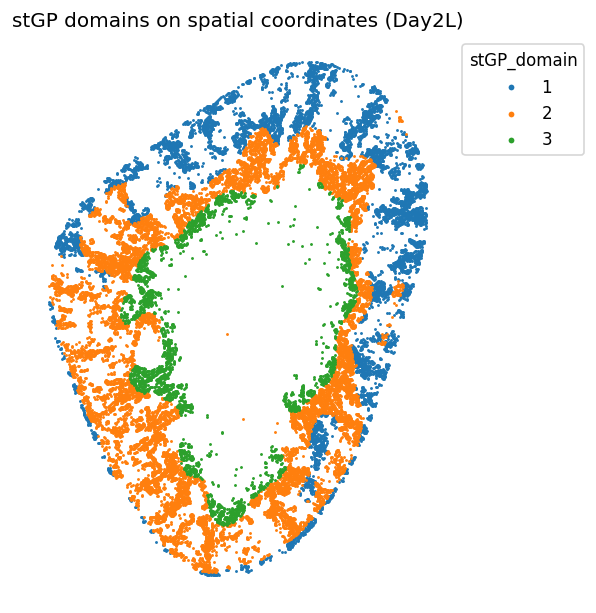

### What the stGP domains show
The domains are spatially coherent rather than randomly mixed. This is the first evidence that day 2 Inj-PT heterogeneity has tissue architecture: an inner/corticomedullary injury-front-like region coexists with broader cortical domains. The biological interpretation is assigned below, after marker and neighborhood validation.

In [3]:
xy = np.asarray(adata.obsm["spatial"])
domain_labels = adata.obs["stGP_domain"].astype(str).to_numpy()

fig, ax = plt.subplots(figsize=(6, 5), constrained_layout=True)
for label in adata.obs["stGP_domain"].cat.categories:
    mask = domain_labels == str(label)
    ax.scatter(xy[mask, 0], xy[mask, 1], s=3, linewidths=0, rasterized=True, label=str(label))

ax.set_aspect("equal")
ax.invert_yaxis()
ax.axis("off")
ax.set_title(f"stGP domains on spatial coordinates ({label_suffix})")
ax.legend(title="stGP_domain", markerscale=2, bbox_to_anchor=(1.02, 1), loc="upper left")

fig.savefig(FIG_DIR / f"{label_suffix}_stgp_domains_spatial.png", dpi=300, bbox_inches="tight")
plt.show()

display(Markdown(
    "### What the stGP domains show\n"
    "The domains are spatially coherent rather than randomly mixed. This is the first evidence that day 2 Inj-PT heterogeneity has tissue architecture: an inner/corticomedullary injury-front-like region coexists with broader cortical domains. The biological interpretation is assigned below, after marker and neighborhood validation."
))


## 3. Infer a state-continuum pseudotime

All cells in this notebook come from the same time point, so the Slingshot result should be interpreted as a state-continuum or fate-potential axis, not chronological time. Domain 3 is used as the root because the spatial map places it near the inner/corticomedullary injury-front region and it carries strong acute-injury evidence; the inferred curve then asks how day 2 Inj-PT states are arranged from severe injury-front toward alternative repair-associated states.

In [4]:
DRM = np.asarray(adata.obsm["X_stgp_spatial"])
if DRM.shape[0] != adata.n_obs:
    DRM = DRM.T
adata.obsm["X_DRM"] = np.asarray(DRM)
adata.obs["clusterlabel"] = pd.Categorical(adata.obs["stGP_domain"].astype(str))

cats = adata.obs["clusterlabel"].cat.categories.astype(str)
print("Cluster categories:", list(cats))

Cluster categories: ['1', '2', '3']


In [5]:
start_cluster = "3"
start_node = list(cats).index(start_cluster)
print(f"Start cluster: {start_cluster} (start_node={start_node})")

sl = Slingshot(
    adata,
    celltype_key="clusterlabel",
    obsm_key="X_DRM",
    start_node=start_node,
)
sl.fit(num_epochs=N_EPOCHS)

Start cluster: 3 (start_node=2)


  0%|          | 0/10 [00:00<?, ?it/s]/home/byual/anaconda3/envs/NicheScope/lib/python3.9/site-packages/pyslingshot/slingshot.py:333: RuntimeWarning: invalid value encountered in divide
  cell_weights = z_prime / np.nanmax(z_prime, axis=1, keepdims=True) #rowMins(D) / D
 10%|█         | 1/10 [01:09<10:26, 69.63s/it]/home/byual/anaconda3/envs/NicheScope/lib/python3.9/site-packages/pyslingshot/slingshot.py:333: RuntimeWarning: invalid value encountered in divide
  cell_weights = z_prime / np.nanmax(z_prime, axis=1, keepdims=True) #rowMins(D) / D
100%|██████████| 10/10 [12:13<00:00, 73.37s/it]


In [6]:
adata.obs["slingPseudotime_1"] = sl.unified_pseudotime

if sl.curves is not None and sl.cell_weights is not None:
    for l_idx, curve in enumerate(sl.curves):
        pt = curve.pseudotimes_interp.copy()
        weight = sl.cell_weights[:, l_idx].copy()
        pt[weight <= 0] = np.nan
        adata.obs[f"slingPseudotime_{l_idx + 1}"] = pt
        adata.obs[f"slingCurveWeight_{l_idx + 1}"] = weight


## 4. Map the state continuum back to tissue space

The key question is spatial, not just transcriptional: do day 2 Inj-PT cells form coherent anatomical domains? The spatial domain plot and pseudotime gradient test whether the stGP embedding corresponds to a reproducible tissue architecture, especially an inner injury-front ring and broader cortical states.

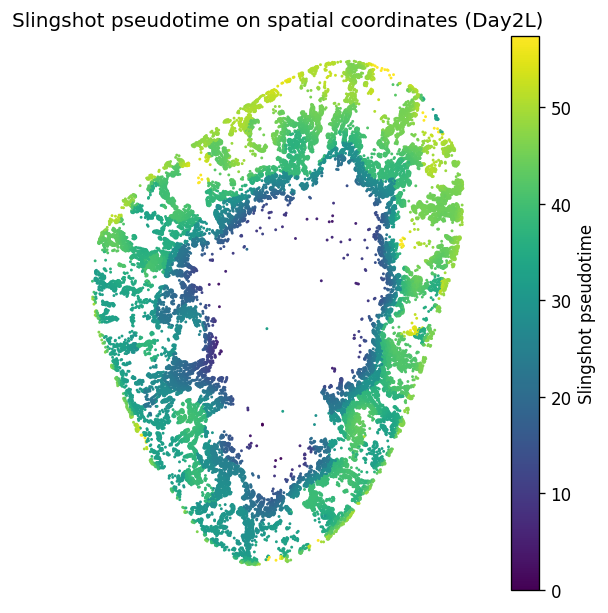

In [7]:
xy = np.asarray(adata.obsm["spatial"])
pt = adata.obs["slingPseudotime_1"].to_numpy(dtype=float)

fig, ax = plt.subplots(figsize=(6, 5), constrained_layout=True)

scat = ax.scatter(
    xy[:, 0], xy[:, 1], c=pt, s=3, cmap="viridis", linewidths=0, rasterized=True
)
ax.set_aspect("equal")
ax.invert_yaxis()
ax.axis("off")
ax.set_title(f"Slingshot pseudotime on spatial coordinates ({label_suffix})")
plt.colorbar(scat, ax=ax, label="Slingshot pseudotime")

fig.savefig(FIG_DIR / f"{label_suffix}_slingshot_pseudotime_spatial.png", dpi=300, bbox_inches="tight")
plt.show()

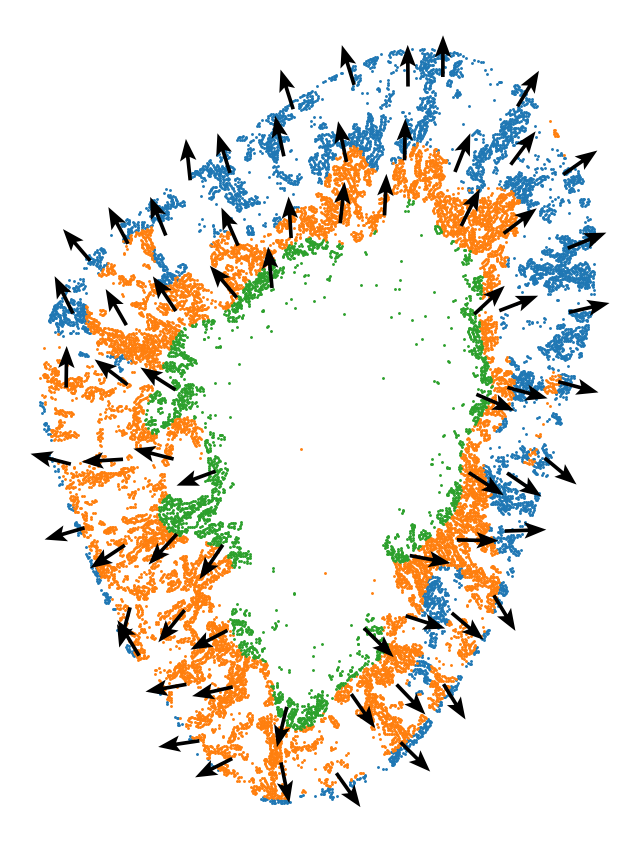

In [8]:
GRIDNUM = 10
MIN_CELLS_PER_GRID = 20
ARROW_LENGTH_FRAC = 0.75

xy = np.asarray(adata.obsm["spatial"])
pt = adata.obs["slingPseudotime_1"].to_numpy(dtype=float)
valid = np.isfinite(pt) & np.all(np.isfinite(xy), axis=1)
xy_valid = xy[valid]
pt_valid = pt[valid]
if xy_valid.size == 0:
    raise ValueError("No finite pseudotime values available for arrow overlay.")

x_edges = np.linspace(xy_valid[:, 0].min(), xy_valid[:, 0].max(), GRIDNUM + 1)
y_edges = np.linspace(xy_valid[:, 1].min(), xy_valid[:, 1].max(), GRIDNUM + 1)
x_bin = np.clip(np.digitize(xy_valid[:, 0], x_edges) - 1, 0, GRIDNUM - 1)
y_bin = np.clip(np.digitize(xy_valid[:, 1], y_edges) - 1, 0, GRIDNUM - 1)

mean_pt = np.full((GRIDNUM, GRIDNUM), np.nan)
mean_xy = np.full((GRIDNUM, GRIDNUM, 2), np.nan)
counts = np.zeros((GRIDNUM, GRIDNUM), dtype=int)

for i in range(GRIDNUM):
    for j in range(GRIDNUM):
        m = (x_bin == i) & (y_bin == j)
        counts[i, j] = int(m.sum())
        if counts[i, j] >= MIN_CELLS_PER_GRID:
            mean_pt[i, j] = float(np.nanmean(pt_valid[m]))
            mean_xy[i, j] = np.nanmean(xy_valid[m], axis=0)

arrow_start = []
arrow_vec = []
for i in range(GRIDNUM):
    for j in range(GRIDNUM):
        if not np.isfinite(mean_pt[i, j]):
            continue
        grad = np.zeros(2, dtype=float)
        center = mean_xy[i, j]
        for di in (-1, 0, 1):
            for dj in (-1, 0, 1):
                if di == 0 and dj == 0:
                    continue
                ni, nj = i + di, j + dj
                if ni < 0 or ni >= GRIDNUM or nj < 0 or nj >= GRIDNUM:
                    continue
                if not np.isfinite(mean_pt[ni, nj]):
                    continue
                direction = mean_xy[ni, nj] - center
                dist = np.linalg.norm(direction)
                if dist == 0:
                    continue
                grad += (mean_pt[ni, nj] - mean_pt[i, j]) * direction / dist
        norm = np.linalg.norm(grad)
        if norm > 0:
            arrow_start.append(center)
            arrow_vec.append(grad / norm)

arrow_start = np.asarray(arrow_start)
arrow_vec = np.asarray(arrow_vec)
cell_size = min(np.diff(x_edges).mean(), np.diff(y_edges).mean())
arrow_vec = arrow_vec * cell_size * ARROW_LENGTH_FRAC

fig, ax = plt.subplots(figsize=(7, 7), constrained_layout=True)
for label in adata.obs["clusterlabel"].cat.categories:
    mask = adata.obs["clusterlabel"].astype(str).to_numpy() == str(label)
    ax.scatter(xy[mask, 0], xy[mask, 1], s=3, linewidths=0, rasterized=True)

if len(arrow_start) > 0:
    ax.quiver(
        arrow_start[:, 0], arrow_start[:, 1],
        arrow_vec[:, 0], arrow_vec[:, 1],
        angles="xy", scale_units="xy", scale=1,
        color="black", width=0.006,
        headwidth=4.5, headlength=6.0, headaxislength=5.0,
    )

ax.set_aspect("equal")
ax.invert_yaxis()
ax.axis("off")
fig.savefig(FIG_DIR / f"{label_suffix}_slingshot_arrow_overlay.png", dpi=300, bbox_inches="tight")
plt.show()

In [9]:
OUT_H5AD = OUT_DIR / f"{label_suffix}_stgp_cluster_slingshot.h5ad"
OUT_OBS = OUT_DIR / f"{label_suffix}_stgp_cluster_slingshot_obs.csv"

adata.write_h5ad(OUT_H5AD, compression="gzip")
adata.obs.to_csv(OUT_OBS)

print(f"Saved trajectory AnnData: {OUT_H5AD.resolve()}")
print(f"Saved trajectory obs: {OUT_OBS.resolve()}")

Saved trajectory AnnData: /import/home4/byual/stGP-0707/RealData_MouseKidneyXenium/Results/stgp/Inj_PT_L/pseudotime_Day2L/Day2L_stgp_cluster_slingshot.h5ad
Saved trajectory obs: /import/home4/byual/stGP-0707/RealData_MouseKidneyXenium/Results/stgp/Inj_PT_L/pseudotime_Day2L/Day2L_stgp_cluster_slingshot_obs.csv


## 5. Validate biological meaning of the domains

The stGP domains are not assumed to be the paper's seven PT states. Instead, we validate them as spatially organized Inj-PT repair states. The marker scores test molecular programs reported in the kidney paper: acute injury/stress (`Havcr1`, `Krt20`, `Plin2`), recovering metabolic repair (`Cxcl12`, `Haao`, `Kynu`, `Hmgcs2`), and maladaptive/pre-FR adhesion or profibrotic activation (`Vcam1`, `Serpine1`, `Cd44`, `Klf5`). We then ask whether these molecular programs align with BBKNN PT-state labels, CN4/CN7 neighborhoods, and 55 um local fibroblast/immune composition.

,program,score_col,n_present,present_genes,missing_genes
0,acute_injury,acute_injury_score,3,"Havcr1, Krt20, Plin2","Srxn1, Cdkn1a, Plk3, Tnfrsf12a"
1,recovery_metabolic,recovery_metabolic_score,4,"Cxcl12, Haao, Kynu, Hmgcs2",
2,maladaptive_pre_FR,maladaptive_pre_FR_score,4,"Vcam1, Serpine1, Cd44, Klf5",


acute_injury_score               recovery_metabolic_score         \
                          mean median    std                     mean median   
stGP_domain                                                                    
1                       -0.493 -0.565  0.560                    0.325  0.248   
2                        0.089  0.050  0.711                   -0.087 -0.276   
3                        0.699  0.796  0.633                   -0.344 -0.495   

                   maladaptive_pre_FR_score                
               std                     mean median    std  
stGP_domain                                                
1            0.676                   -0.257 -0.428  0.383  
2            0.522                    0.044 -0.202  0.615  
3            0.329                    0.375  0.308  0.691

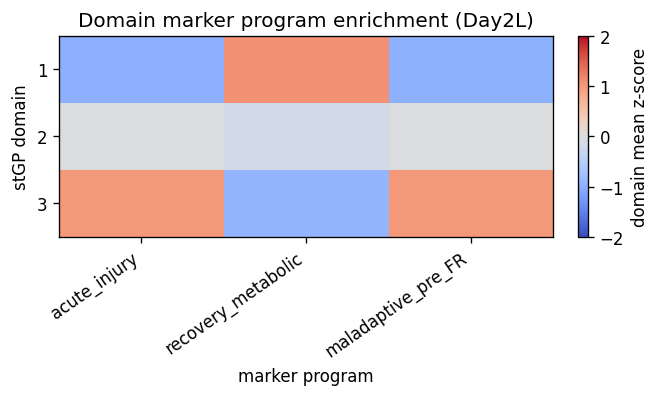

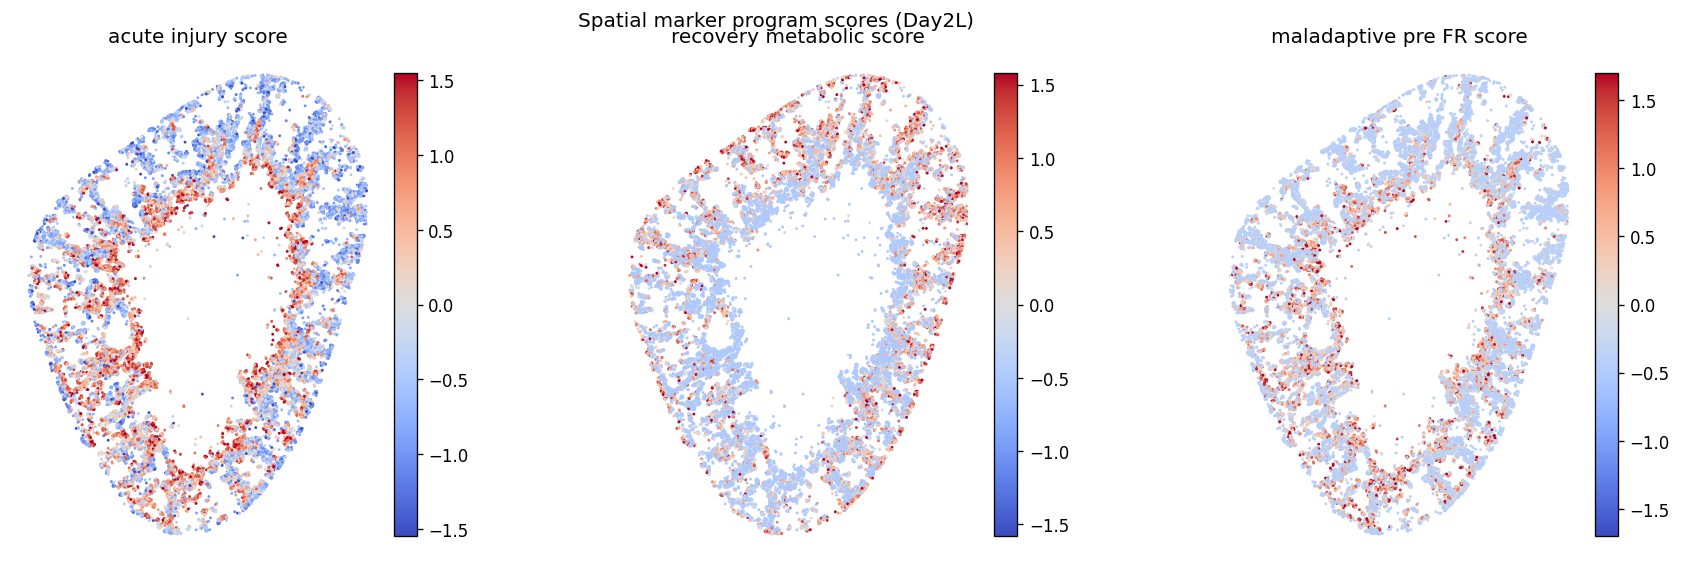

In [10]:
from IPython.display import Markdown

DOMAIN_MARKER_SETS = {
    "acute_injury": ["Havcr1", "Krt20", "Plin2", "Srxn1", "Cdkn1a", "Plk3", "Tnfrsf12a"],
    "recovery_metabolic": ["Cxcl12", "Haao", "Kynu", "Hmgcs2"],
    "maladaptive_pre_FR": ["Vcam1", "Serpine1", "Cd44", "Klf5"],
}


def _present_genes(adata_obj, genes):
    """Return var_names matching the requested gene symbols, ignoring case."""
    lookup = {str(g).upper(): str(g) for g in adata_obj.var_names}
    return [lookup[g.upper()] for g in genes if g.upper() in lookup]


def _dense_matrix(x):
    return x.toarray() if sp.issparse(x) else np.asarray(x)


def add_zscore_gene_program(adata_obj, genes, score_name):
    present = _present_genes(adata_obj, genes)
    missing = [g for g in genes if g.upper() not in {p.upper() for p in present}]
    if len(present) == 0:
        adata_obj.obs[score_name] = np.nan
        return present, missing

    X = _dense_matrix(adata_obj[:, present].X).astype(float)
    gene_mean = np.nanmean(X, axis=0, keepdims=True)
    gene_sd = np.nanstd(X, axis=0, keepdims=True)
    gene_sd[gene_sd == 0] = 1.0
    adata_obj.obs[score_name] = np.nanmean((X - gene_mean) / gene_sd, axis=1)
    return present, missing


marker_availability = []
score_cols = []
for program, genes in DOMAIN_MARKER_SETS.items():
    score_col = f"{program}_score"
    present, missing = add_zscore_gene_program(adata, genes, score_col)
    score_cols.append(score_col)
    marker_availability.append({
        "program": program,
        "score_col": score_col,
        "n_present": len(present),
        "present_genes": ", ".join(present),
        "missing_genes": ", ".join(missing),
    })

marker_availability = pd.DataFrame(marker_availability)
marker_availability.to_csv(OUT_DIR / f"{label_suffix}_domain_marker_gene_availability.csv", index=False)
display(marker_availability)

domain_score_summary = (
    adata.obs.groupby("stGP_domain", observed=True)[score_cols]
    .agg(["mean", "median", "std"])
    .round(3)
)
domain_score_summary.to_csv(OUT_DIR / f"{label_suffix}_stgp_domain_marker_score_summary.csv")
display(domain_score_summary)

# Heatmap uses domain-level mean scores scaled within each score to emphasize relative enrichment.
domain_score_mean = adata.obs.groupby("stGP_domain", observed=True)[score_cols].mean()
plot_mat = domain_score_mean.copy()
plot_mat = (plot_mat - plot_mat.mean(axis=0)) / plot_mat.std(axis=0).replace(0, np.nan)
plot_mat = plot_mat.fillna(0)

fig, ax = plt.subplots(figsize=(5.4, 3.2), constrained_layout=True)
im = ax.imshow(plot_mat.to_numpy(), cmap="coolwarm", aspect="auto", vmin=-2, vmax=2)
ax.set_xticks(np.arange(len(score_cols)))
ax.set_xticklabels([c.replace("_score", "") for c in score_cols], rotation=35, ha="right")
ax.set_yticks(np.arange(plot_mat.shape[0]))
ax.set_yticklabels(plot_mat.index.astype(str))
ax.set_xlabel("marker program")
ax.set_ylabel("stGP domain")
ax.set_title(f"Domain marker program enrichment ({label_suffix})")
plt.colorbar(im, ax=ax, label="domain mean z-score")
fig.savefig(FIG_DIR / f"{label_suffix}_stgp_domain_marker_score_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

xy = np.asarray(adata.obsm["spatial"])
fig, axes = plt.subplots(1, len(score_cols), figsize=(5 * len(score_cols), 4.5), constrained_layout=True)
if len(score_cols) == 1:
    axes = [axes]
for ax, score_col in zip(axes, score_cols):
    values = adata.obs[score_col].to_numpy(dtype=float)
    vmax = np.nanpercentile(np.abs(values), 98)
    scat = ax.scatter(
        xy[:, 0], xy[:, 1], c=values, s=3, cmap="coolwarm",
        vmin=-vmax, vmax=vmax, linewidths=0, rasterized=True,
    )
    ax.set_aspect("equal")
    ax.invert_yaxis()
    ax.axis("off")
    ax.set_title(score_col.replace("_", " "))
    plt.colorbar(scat, ax=ax, fraction=0.046, pad=0.02)
fig.suptitle(f"Spatial marker program scores ({label_suffix})", y=1.02)
fig.savefig(FIG_DIR / f"{label_suffix}_marker_program_scores_spatial.png", dpi=300, bbox_inches="tight")
plt.show()

score_mean_simple = adata.obs.groupby("stGP_domain", observed=True)[score_cols].mean()
marker_lines = []
for score_col in score_cols:
    top_domain = score_mean_simple[score_col].idxmax()
    marker_lines.append(f"- `{score_col}` is highest in domain `{top_domain}`.")


Each score is a relative program activity within Day2 Inj-PT cells: genes are z-scored across these cells and averaged within the curated marker set. These scores are not new cell-type labels; they are targeted validation axes from the kidney injury paper.


### BBKNN reference labels

`pt_ad_BBKNN_annotated.h5ad` is used only as an external PT state reference for interpreting the three stGP spatial domains. In the original PT trajectory analysis, all PT cells were normalized, embedded by PCA, corrected for sample/time-slice batch effects with BBKNN using `ident` as the batch key, and then clustered with Leiden at resolution 2 into `bbknn_res2`. The manually curated `celltype_bbknn` column maps those Leiden clusters to biological PT states: `Healthy_S1`, `Healthy_S2`, `Healthy_S3`, `Inj_S1`, `Inj_S2`, `Inj_S3`, and `Failed_repair`.

Here, `celltype_bbknn` and `bbknn_res2` are not recomputed and are not used to define the stGP domains. They are imported only to test whether each day 2 Inj-PT spatial domain is dominated by segment identity or aligns with the repair/failure fate interpretation.

In [11]:
import h5py

PT_REF_PATH = ROOT / "data" / "pt_ad_BBKNN_annotated.h5ad"
REF_OBS_COLS = ["celltype_bbknn", "bbknn_res2"]


def _decode_h5_array(values):
    return np.asarray([
        v.decode("utf-8") if isinstance(v, (bytes, np.bytes_)) else v
        for v in values
    ], dtype=object)


def _read_h5_obs_column(h5_file, col):
    obj = h5_file["obs"][col]
    if isinstance(obj, h5py.Group) and {"categories", "codes"}.issubset(obj.keys()):
        categories = _decode_h5_array(obj["categories"][:])
        codes = np.asarray(obj["codes"][:], dtype=int)
        values = np.full(codes.shape[0], None, dtype=object)
        valid = codes >= 0
        values[valid] = categories[codes[valid]]
        return values
    return _decode_h5_array(obj[:])


if PT_REF_PATH.exists():
    with h5py.File(PT_REF_PATH, "r") as f:
        ref_cols = [c for c in REF_OBS_COLS if c in f["obs"]]
        ref_obs = pd.DataFrame(
            {col: _read_h5_obs_column(f, col) for col in ref_cols},
            index=_decode_h5_array(f["obs/_index"][:]).astype(str),
        )

    common_obs = adata.obs_names.intersection(ref_obs.index)
    for col in ref_cols:
        adata.obs[f"pt_ref_{col}"] = pd.Series(index=adata.obs_names, dtype="object")
        adata.obs.loc[common_obs, f"pt_ref_{col}"] = ref_obs.loc[common_obs, col].astype(str).to_numpy()
        adata.obs[f"pt_ref_{col}"] = pd.Categorical(adata.obs[f"pt_ref_{col}"])
else:
    print(f"PT reference not found: {PT_REF_PATH}")

composition_cols = [
    c for c in [
        "pt_ref_celltype_bbknn",
        "pt_ref_bbknn_res2",
    ]
    if c in adata.obs.columns
]

composition_tables = {}
for col in composition_cols:
    table = pd.crosstab(adata.obs["stGP_domain"], adata.obs[col], normalize="index")
    table = table.loc[:, table.sum(axis=0).sort_values(ascending=False).index]
    composition_tables[col] = table
    table.to_csv(OUT_DIR / f"{label_suffix}_stgp_domain_{col}_fraction.csv")
    print(f"\n{col} fraction by stGP_domain")
    display(table.round(3))

    fig, ax = plt.subplots(figsize=(7.5, 3.4), constrained_layout=True)
    table.plot(kind="bar", stacked=True, ax=ax, width=0.85, colormap="tab20")
    ax.set_ylabel("fraction within domain")
    ax.set_xlabel("stGP domain")
    ax.set_title(f"{col} composition by stGP domain ({label_suffix})")
    ax.legend(title=col, bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
    fig.savefig(FIG_DIR / f"{label_suffix}_stgp_domain_{col}_stacked_fraction.png", dpi=300, bbox_inches="tight")
    plt.show()

if "CN" in adata.obs.columns:
    cn_count = pd.crosstab(adata.obs["stGP_domain"], adata.obs["CN"])
    cn_frac = pd.crosstab(adata.obs["stGP_domain"], adata.obs["CN"], normalize="index")
    cn_count.to_csv(OUT_DIR / f"{label_suffix}_stgp_domain_CN_count.csv")
    cn_frac.to_csv(OUT_DIR / f"{label_suffix}_stgp_domain_CN_fraction.csv")

    cn_focus_cols = [c for c in cn_frac.columns if ("CN4" in str(c)) or ("CN7" in str(c))]
    if len(cn_focus_cols) > 0:
        display(cn_frac[cn_focus_cols].round(3))

PT reference not found: /import/home4/byual/stGP-0707/RealData_MouseKidneyXenium/data/pt_ad_BBKNN_annotated.h5ad


CN,CN4: Injured Proximal Tubule,CN7: Fibro-inflammatory Niche
stGP_domain,,
1,0.714,0.044
2,0.778,0.064
3,0.698,0.104


Skipping missing neighbor reference: /import/home4/byual/stGP-0707/RealData_MouseKidneyXenium/data/processed/EC.h5ad
Skipping missing neighbor reference: /import/home4/byual/stGP-0707/RealData_MouseKidneyXenium/data/processed/PTS1.h5ad
Skipping missing neighbor reference: /import/home4/byual/stGP-0707/RealData_MouseKidneyXenium/data/processed/PTS2.h5ad
Skipping missing neighbor reference: /import/home4/byual/stGP-0707/RealData_MouseKidneyXenium/data/processed/PTS3.h5ad
Skipping missing neighbor reference: /import/home4/byual/stGP-0707/RealData_MouseKidneyXenium/data/processed/FR_PT.h5ad
Loaded 22,585 reference cells for 55 um neighborhood analysis


,n_reference_cells
neighbor_class,
Fibroblast,18839
Immune,3746


,neighbor55_count_Fibroblast_mean,neighbor55_count_Immune_mean,neighbor55_count_Endothelial_mean,neighbor55_count_Healthy_PTS1_mean,neighbor55_count_Healthy_PTS2_mean,neighbor55_count_Healthy_PTS3_mean,neighbor55_count_FR_PT_mean,neighbor55_frac_Fibroblast_mean,neighbor55_frac_Immune_mean,neighbor55_frac_Endothelial_mean,neighbor55_frac_Healthy_PTS1_mean,neighbor55_frac_Healthy_PTS2_mean,neighbor55_frac_Healthy_PTS3_mean,neighbor55_frac_FR_PT_mean,total_reference_cells_mean
stGP_domain,,,,,,,,,,,,,,,
1,7.457,0.884,0.0,0.0,0.0,0.0,0.0,0.889,0.111,0.0,0.0,0.0,0.0,0.0,8.341
2,9.132,1.161,0.0,0.0,0.0,0.0,0.0,0.872,0.128,0.0,0.0,0.0,0.0,0.0,10.293
3,12.213,2.522,0.0,0.0,0.0,0.0,0.0,0.839,0.161,0.0,0.0,0.0,0.0,0.0,14.735


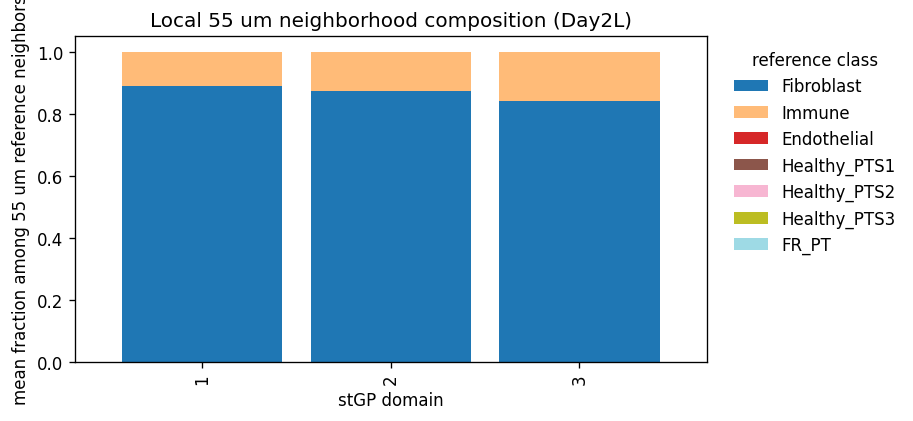

In [12]:
import h5py

NEIGHBOR_RADIUS_UM = 55
PROCESSED_DIR = ROOT / "data" / "processed"
NEIGHBOR_REFERENCE_FILES = {
    "Fibroblast": "Fib.h5ad",
    "Immune": "Immune.h5ad",
    "Endothelial": "EC.h5ad",
    "Healthy_PTS1": "PTS1.h5ad",
    "Healthy_PTS2": "PTS2.h5ad",
    "Healthy_PTS3": "PTS3.h5ad",
    "FR_PT": "FR_PT.h5ad",
}


def _load_spatial_reference(processed_dir, label_suffix, file_map):
    frames = []
    for label, fname in file_map.items():
        path = processed_dir / fname
        if not path.exists():
            print(f"Skipping missing neighbor reference: {path}")
            continue
        with h5py.File(path, "r") as f:
            if "obs" not in f or "ident" not in f["obs"] or "obsm" not in f or "spatial" not in f["obsm"]:
                print(f"Skipping {path.name}: missing ident or spatial coordinates")
                continue
            ident = _read_h5_obs_column(f, "ident").astype(str)
            mask = ident == str(label_suffix)
            if mask.sum() == 0:
                continue
            coords = np.asarray(f["obsm/spatial"])[mask]
            index = _decode_h5_array(f["obs/_index"][:]).astype(str)[mask]
        frame = pd.DataFrame({
            "obs_name": index,
            "neighbor_class": label,
            "x": coords[:, 0],
            "y": coords[:, 1],
        })
        frames.append(frame)
    if len(frames) == 0:
        return pd.DataFrame(columns=["obs_name", "neighbor_class", "x", "y"])
    return pd.concat(frames, ignore_index=True)


neighbor_ref = _load_spatial_reference(PROCESSED_DIR, label_suffix, NEIGHBOR_REFERENCE_FILES)
print(f"Loaded {len(neighbor_ref):,} reference cells for {NEIGHBOR_RADIUS_UM} um neighborhood analysis")
display(neighbor_ref["neighbor_class"].value_counts().rename("n_reference_cells").to_frame())

if len(neighbor_ref) > 0:
    ref_xy = neighbor_ref[["x", "y"]].to_numpy(dtype=float)
    ref_class = neighbor_ref["neighbor_class"].to_numpy()
    query_xy = np.asarray(adata.obsm["spatial"])
    neighbor_classes = list(NEIGHBOR_REFERENCE_FILES.keys())

    nbrs = NearestNeighbors(radius=NEIGHBOR_RADIUS_UM, metric="euclidean").fit(ref_xy)
    neighbor_idx = nbrs.radius_neighbors(query_xy, return_distance=False)

    neighbor_counts = np.zeros((adata.n_obs, len(neighbor_classes)), dtype=int)
    for i, idx in enumerate(neighbor_idx):
        if len(idx) == 0:
            continue
        counts = pd.Series(ref_class[idx]).value_counts()
        for j, cls in enumerate(neighbor_classes):
            neighbor_counts[i, j] = int(counts.get(cls, 0))

    count_cols = [f"neighbor55_count_{cls}" for cls in neighbor_classes]
    frac_cols = [f"neighbor55_frac_{cls}" for cls in neighbor_classes]
    count_df = pd.DataFrame(neighbor_counts, index=adata.obs_names, columns=count_cols)
    total_neighbors = neighbor_counts.sum(axis=1)
    frac = np.divide(
        neighbor_counts,
        total_neighbors[:, None],
        out=np.full(neighbor_counts.shape, np.nan, dtype=float),
        where=total_neighbors[:, None] > 0,
    )
    frac_df = pd.DataFrame(frac, index=adata.obs_names, columns=frac_cols)

    for col in count_cols:
        adata.obs[col] = count_df[col]
    for col in frac_cols:
        adata.obs[col] = frac_df[col]
    adata.obs["neighbor55_total_reference_cells"] = total_neighbors

    neighbor_domain_summary = pd.concat(
        [
            adata.obs.groupby("stGP_domain", observed=True)[count_cols].mean().add_suffix("_mean"),
            adata.obs.groupby("stGP_domain", observed=True)[frac_cols].mean().add_suffix("_mean"),
            adata.obs.groupby("stGP_domain", observed=True)["neighbor55_total_reference_cells"].mean().rename("total_reference_cells_mean"),
        ],
        axis=1,
    )
    neighbor_domain_summary.to_csv(OUT_DIR / f"{label_suffix}_stgp_domain_neighbor55um_summary.csv")
    display(neighbor_domain_summary.round(3))

    frac_summary = adata.obs.groupby("stGP_domain", observed=True)[frac_cols].mean()
    frac_summary.columns = [c.replace("neighbor55_frac_", "") for c in frac_summary.columns]
    fig, ax = plt.subplots(figsize=(7.5, 3.4), constrained_layout=True)
    frac_summary.plot(kind="bar", stacked=True, ax=ax, width=0.85, colormap="tab20")
    ax.set_ylabel("mean fraction among 55 um reference neighbors")
    ax.set_xlabel("stGP domain")
    ax.set_title(f"Local 55 um neighborhood composition ({label_suffix})")
    ax.legend(title="reference class", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
    fig.savefig(FIG_DIR / f"{label_suffix}_stgp_domain_neighbor55um_stacked_fraction.png", dpi=300, bbox_inches="tight")
    plt.show()
else:
    print("No processed reference cells were available for local neighborhood analysis.")

,n_cells,mean_acute_injury_score,median_acute_injury_score,mean_recovery_metabolic_score,median_recovery_metabolic_score,mean_maladaptive_pre_FR_score,median_maladaptive_pre_FR_score,mean_slingPseudotime_1,median_slingPseudotime_1,mean_slingCurveWeight_1,...,neighbor55_mean_frac_Healthy_PTS1,neighbor55_mean_frac_Healthy_PTS2,neighbor55_mean_frac_Healthy_PTS3,neighbor55_mean_frac_FR_PT,top_marker_program,recovery_integrated_evidence,acute_integrated_evidence,maladaptive_integrated_evidence,integrated_annotation,interpretation_note
stGP_domain,,,,,,,,,,,,,,,,,,,,,
1,5773,-0.4926,-0.5653,0.3251,0.2478,-0.2574,-0.4282,44.7956,44.2744,1.0,...,0.0,0.0,0.0,0.0,recovery_metabolic,1.0677,-1.3672,-1.8619,recovering / metabolic Inj-PT,integrated label uses marker scores plus CN4/C...
2,11003,0.0888,0.0499,-0.0870,-0.2759,0.0441,-0.2023,32.6591,32.5522,1.0,...,0.0,0.0,0.0,0.0,acute_injury,-0.1530,1.1174,-0.2418,acute-stress transitional Inj-PT,integrated label uses marker scores plus CN4/C...
3,2673,0.6986,0.7965,-0.3441,-0.4947,0.3746,0.3085,18.4669,19.1206,1.0,...,0.0,0.0,0.0,0.0,acute_injury,-0.9147,0.2498,2.1037,maladaptive-biased injury-front / pre-FR Inj-PT,integrated label uses marker scores plus CN4/C...


### Integrated domain interpretation
The final label is intentionally not assigned from the largest marker score alone. It combines marker activity with the original CN4/CN7 neighborhood labels and local 55 um fibroblast/immune context, because the kidney paper defines maladaptive repair as both a PT state and a fibro-inflammatory spatial niche.
- Domain 1: **recovering / metabolic Inj-PT**; top marker program = `recovery_metabolic`.
- Domain 2: **acute-stress transitional Inj-PT**; top marker program = `acute_injury`.
- Domain 3: **maladaptive-biased injury-front / pre-FR Inj-PT**; top marker program = `acute_injury`.

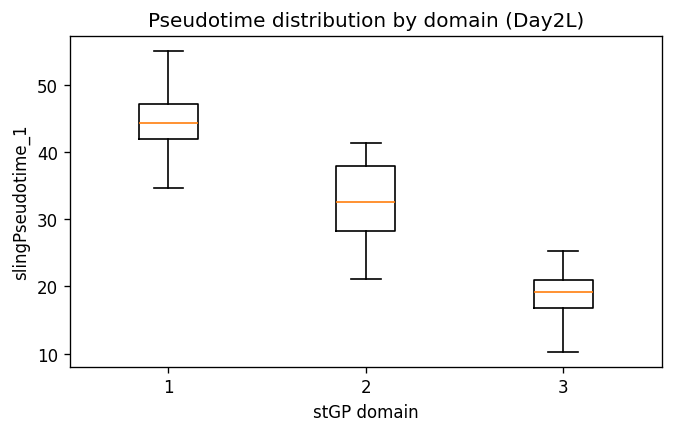

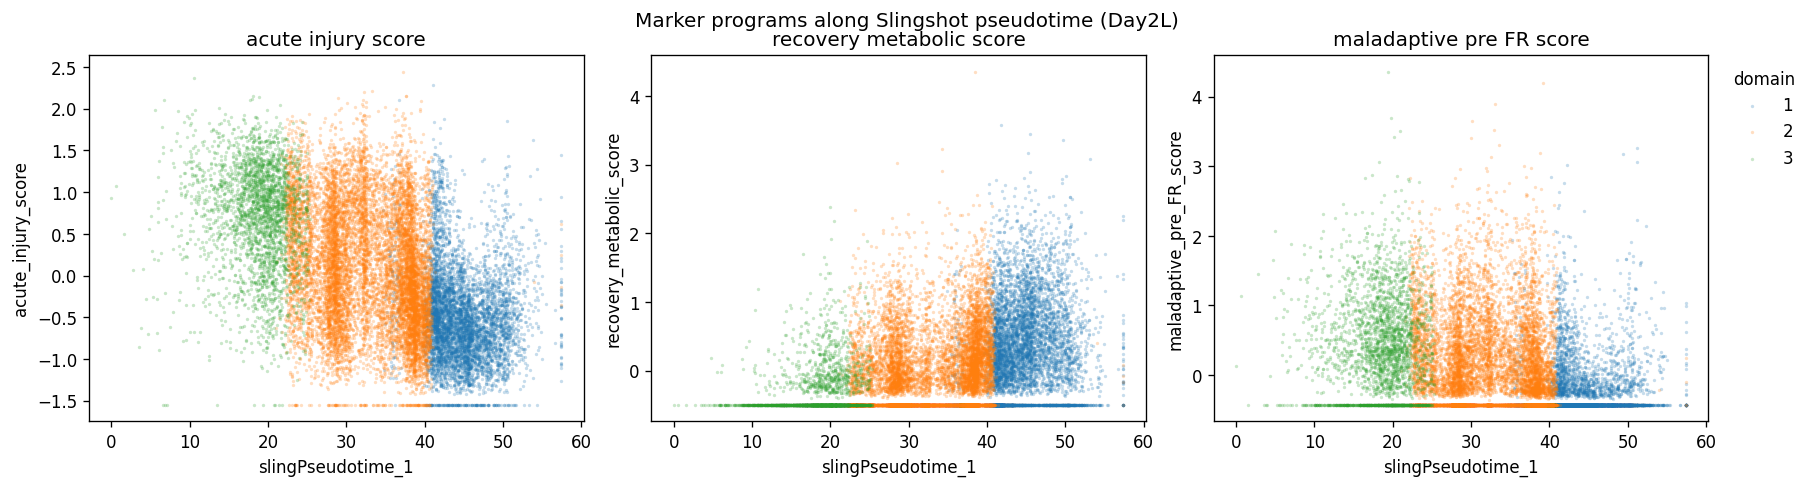

In [13]:
# Integrate marker, CN, neighborhood, and pseudotime evidence into one domain-level table.
domain_validation = pd.DataFrame(index=adata.obs["stGP_domain"].cat.categories.astype(str))
domain_validation.index.name = "stGP_domain"
domain_validation["n_cells"] = adata.obs["stGP_domain"].astype(str).value_counts().reindex(domain_validation.index).astype(int)

for score_col in score_cols:
    domain_validation[f"mean_{score_col}"] = adata.obs.groupby("stGP_domain", observed=True)[score_col].mean().reindex(domain_validation.index)
    domain_validation[f"median_{score_col}"] = adata.obs.groupby("stGP_domain", observed=True)[score_col].median().reindex(domain_validation.index)

pt_cols = [c for c in adata.obs.columns if c.startswith("slingPseudotime")]
weight_cols = [c for c in adata.obs.columns if c.startswith("slingCurveWeight")]
for col in pt_cols + weight_cols:
    domain_validation[f"mean_{col}"] = adata.obs.groupby("stGP_domain", observed=True)[col].mean().reindex(domain_validation.index)
    domain_validation[f"median_{col}"] = adata.obs.groupby("stGP_domain", observed=True)[col].median().reindex(domain_validation.index)

if "CN" in adata.obs.columns:
    cn_frac = pd.crosstab(adata.obs["stGP_domain"], adata.obs["CN"], normalize="index")
    for cn_label in cn_frac.columns:
        if ("CN4" in str(cn_label)) or ("CN7" in str(cn_label)):
            domain_validation[f"frac_{cn_label}"] = cn_frac[cn_label].reindex(domain_validation.index)

if "pt_ref_celltype_bbknn" in adata.obs.columns:
    pt_state_frac = pd.crosstab(adata.obs["stGP_domain"], adata.obs["pt_ref_celltype_bbknn"], normalize="index")
    for state in ["Inj_S1", "Inj_S2", "Inj_S3", "Failed_repair", "Healthy_S1", "Healthy_S2", "Healthy_S3"]:
        if state in pt_state_frac.columns:
            domain_validation[f"frac_pt_state_{state}"] = pt_state_frac[state].reindex(domain_validation.index)

neighbor_frac_cols = [c for c in adata.obs.columns if c.startswith("neighbor55_frac_")]
for col in neighbor_frac_cols:
    short = col.replace("neighbor55_frac_", "neighbor55_mean_frac_")
    domain_validation[short] = adata.obs.groupby("stGP_domain", observed=True)[col].mean().reindex(domain_validation.index)

mean_score_cols = [f"mean_{c}" for c in score_cols if f"mean_{c}" in domain_validation.columns]
if len(mean_score_cols) > 0:
    top_score_col = domain_validation[mean_score_cols].idxmax(axis=1)
    domain_validation["top_marker_program"] = top_score_col.str.replace("mean_", "", regex=False).str.replace("_score", "", regex=False)


def _z(series):
    series = pd.to_numeric(series, errors="coerce")
    sd = series.std()
    if not np.isfinite(sd) or sd == 0:
        return series * 0
    return (series - series.mean()) / sd


def _first_existing(columns):
    for col in columns:
        if col in domain_validation.columns:
            return col
    return None

cn4_col = next((c for c in domain_validation.columns if c.startswith("frac_CN4")), None)
cn7_col = next((c for c in domain_validation.columns if c.startswith("frac_CN7")), None)
fib_col = "neighbor55_mean_frac_Fibroblast"
imm_col = "neighbor55_mean_frac_Immune"
inj_s3_col = "frac_pt_state_Inj_S3"
fr_col = "frac_pt_state_Failed_repair"

recovery_components = ["mean_recovery_metabolic_score"]
acute_components = ["mean_acute_injury_score", cn4_col]
maladaptive_components = ["mean_maladaptive_pre_FR_score", cn7_col, fib_col, imm_col, inj_s3_col, fr_col]

for name, components in {
    "recovery_integrated_evidence": recovery_components,
    "acute_integrated_evidence": acute_components,
    "maladaptive_integrated_evidence": maladaptive_components,
}.items():
    valid_components = [c for c in components if c is not None and c in domain_validation.columns]
    if len(valid_components) == 0:
        domain_validation[name] = np.nan
    else:
        domain_validation[name] = sum(_z(domain_validation[c]) for c in valid_components)

role_map = {}
available_domains = list(domain_validation.index)
if "recovery_integrated_evidence" in domain_validation:
    recovery_domain = domain_validation["recovery_integrated_evidence"].idxmax()
    role_map[recovery_domain] = "recovering / metabolic Inj-PT"
else:
    recovery_domain = None

remaining = [d for d in available_domains if d not in role_map]
if len(remaining) > 0 and "maladaptive_integrated_evidence" in domain_validation:
    maladaptive_domain = domain_validation.loc[remaining, "maladaptive_integrated_evidence"].idxmax()
    role_map[maladaptive_domain] = "maladaptive-biased injury-front / pre-FR Inj-PT"

remaining = [d for d in available_domains if d not in role_map]
if len(remaining) > 0:
    if "acute_integrated_evidence" in domain_validation:
        acute_domain = domain_validation.loc[remaining, "acute_integrated_evidence"].idxmax()
    else:
        acute_domain = remaining[0]
    role_map[acute_domain] = "acute-stress transitional Inj-PT"

for domain in available_domains:
    role_map.setdefault(domain, "unassigned Inj-PT spatial state")

domain_validation["integrated_annotation"] = pd.Series(role_map).reindex(domain_validation.index)
domain_validation["interpretation_note"] = (
    "integrated label uses marker scores plus CN4/CN7 and 55um fibroblast/immune context; domain IDs are replicate-specific"
)

domain_validation = domain_validation.round(4)
domain_validation.to_csv(OUT_DIR / f"{label_suffix}_stgp_domain_validation_summary.csv")
role_table = domain_validation[["integrated_annotation", "top_marker_program"]].copy()
role_table.to_csv(OUT_DIR / f"{label_suffix}_stgp_domain_integrated_annotation.csv")
display(domain_validation)

annotation_lines = [
    f"- Domain {domain}: **{row['integrated_annotation']}**; top marker program = `{row.get('top_marker_program', 'NA')}`."
    for domain, row in domain_validation.iterrows()
]
display(Markdown("\n".join([
    "### Integrated domain interpretation",
    "The final label is intentionally not assigned from the largest marker score alone. It combines marker activity with the original CN4/CN7 neighborhood labels and local 55 um fibroblast/immune context, because the kidney paper defines maladaptive repair as both a PT state and a fibro-inflammatory spatial niche.",
    *annotation_lines,
])))

if len(pt_cols) > 0:
    pt_col = "slingPseudotime_1" if "slingPseudotime_1" in pt_cols else pt_cols[0]
    domain_order = list(domain_validation.index)

    fig, ax = plt.subplots(figsize=(5.5, 3.5), constrained_layout=True)
    data = [adata.obs.loc[adata.obs["stGP_domain"].astype(str) == d, pt_col].dropna().to_numpy() for d in domain_order]
    ax.boxplot(data, tick_labels=domain_order, showfliers=False)
    ax.set_xlabel("stGP domain")
    ax.set_ylabel(pt_col)
    ax.set_title(f"Pseudotime distribution by domain ({label_suffix})")
    fig.savefig(FIG_DIR / f"{label_suffix}_stgp_domain_pseudotime_boxplot.png", dpi=300, bbox_inches="tight")
    plt.show()

    fig, axes = plt.subplots(1, len(score_cols), figsize=(5 * len(score_cols), 3.8), constrained_layout=True)
    if len(score_cols) == 1:
        axes = [axes]
    for ax, score_col in zip(axes, score_cols):
        for domain in domain_order:
            mask = adata.obs["stGP_domain"].astype(str).to_numpy() == domain
            ax.scatter(
                adata.obs.loc[mask, pt_col],
                adata.obs.loc[mask, score_col],
                s=4, alpha=0.25, linewidths=0, rasterized=True, label=domain,
            )
        ax.set_xlabel(pt_col)
        ax.set_ylabel(score_col)
        ax.set_title(score_col.replace("_", " "))
    axes[-1].legend(title="domain", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
    fig.suptitle(f"Marker programs along Slingshot pseudotime ({label_suffix})", y=1.03)
    fig.savefig(FIG_DIR / f"{label_suffix}_marker_scores_vs_pseudotime.png", dpi=300, bbox_inches="tight")
    plt.show()

In [14]:
# Save the augmented object after adding validation scores and neighborhood summaries.
OUT_H5AD_VALIDATED = OUT_DIR / f"{label_suffix}_stgp_cluster_slingshot_validated.h5ad"
OUT_OBS_VALIDATED = OUT_DIR / f"{label_suffix}_stgp_cluster_slingshot_validated_obs.csv"

adata.write_h5ad(OUT_H5AD_VALIDATED, compression="gzip")
adata.obs.to_csv(OUT_OBS_VALIDATED)

print(f"Saved validated trajectory AnnData: {OUT_H5AD_VALIDATED.resolve()}")
print(f"Saved validated obs table: {OUT_OBS_VALIDATED.resolve()}")
print(f"Validation summaries are in: {OUT_DIR.resolve()}")
print(f"Figures are in: {FIG_DIR.resolve()}")

Saved validated trajectory AnnData: /import/home4/byual/stGP-0707/RealData_MouseKidneyXenium/Results/stgp/Inj_PT_L/pseudotime_Day2L/Day2L_stgp_cluster_slingshot_validated.h5ad
Saved validated obs table: /import/home4/byual/stGP-0707/RealData_MouseKidneyXenium/Results/stgp/Inj_PT_L/pseudotime_Day2L/Day2L_stgp_cluster_slingshot_validated_obs.csv
Validation summaries are in: /import/home4/byual/stGP-0707/RealData_MouseKidneyXenium/Results/stgp/Inj_PT_L/pseudotime_Day2L
Figures are in: /import/home4/byual/stGP-0707/RealData_MouseKidneyXenium/Figures/Inj_PT_L/pseudotime_Day2L
